# 17 综合项目：垃圾短信识别（文本版全模型横评）

**本章目标**：把 13–16 章的"全模型横评"骨架套到**文本数据**上：
5574 条短信，判断是正常短信（ham）还是垃圾短信（spam）。
探索阶段看词频与词云，特征工程用 **TF-IDF** 把文字变成向量，
9 个分类模型同一尺度横评，最后用逻辑回归的系数找出
"最垃圾的词"和"最正常的词"。

> 本章是工程流程章：所有模型直接调用 sklearn / XGBoost 现成接口。
> 数据来自 GitHub 上 justmarkham/pycon-2016-tutorial 仓库的 sms.tsv
> （UCI SMS Spam Collection 的整洁版），已保存本地副本，离线可复现。

项目一句话：**给我一条短信，判断它是正常消息还是垃圾广告**。


## 模型简介与学习参考

| 环节 | 模型 | 在本项目中的角色 |
|---|---|---|
| 特征工程 | TF-IDF（TfidfVectorizer） | 把文字变成稀疏向量 |
| 分类横评（9） | 朴素贝叶斯、逻辑回归、KNN、决策树、SVM(线性核)、SVM(RBF核)、随机森林、GBDT、XGBoost | 同一任务"短信 → 垃圾/正常"横评 |

**学习参考**：

- [scikit-learn：文本特征提取](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)；
- [scikit-learn 官方文档](https://scikit-learn.org/stable/)；
- [justmarkham/pycon-2016-tutorial](https://github.com/justmarkham/pycon-2016-tutorial)（数据来源，GitHub）。

本章按照 **数据 → 探索 → TF-IDF 特征工程 → 建模横评 → 诊断 → 总结** 展开。


## 目录

- [1. 数据：GitHub 来源与类别分布](#data)
- [2. 探索性分析：文本版 EDA](#eda)
  - [2.1 类别分布与短信长度](#length)
  - [2.2 高频词对比](#freq)
  - [2.3 词云](#wordcloud)
- [3. 特征工程：TF-IDF](#tfidf)
- [4. 分类横评：9 个模型](#models)
  - [4.1 模型清单与协议](#model-list)
  - [4.2 交叉验证横评](#cv)
  - [4.3 测试集与混淆矩阵](#test)
  - [4.4 ROC 曲线](#roc)
  - [4.5 错误短信展示](#errors)
- [5. 诊断：垃圾词 vs 正常词](#words)
- [6. 总结与验证](#summary)


<a id="data"></a>
## 1. 数据：GitHub 来源与类别分布

数据来自 GitHub 上 [justmarkham/pycon-2016-tutorial](https://github.com/justmarkham/pycon-2016-tutorial)
仓库的 `sms.tsv`——UCI SMS Spam Collection 的整洁版：5574 条真实短信，
两列（label / message）。垃圾短信占 13.4%，是典型的**类别不平衡**数据。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
DATA_PATH = Path("data/sms.tsv")

if DATA_PATH.exists():
    sms = pd.read_csv(DATA_PATH, sep="\t", encoding="utf-8",
                      header=None, names=["label", "message"])
    source_note = f"本地副本 {DATA_PATH}"
else:
    sms = pd.read_csv(DATA_URL, sep="\t", encoding="utf-8",
                      header=None, names=["label", "message"])
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    sms.to_csv(DATA_PATH, sep="\t", index=False, header=False)
    source_note = "已从 GitHub 下载（justmarkham/pycon-2016-tutorial）并保存本地副本"

print("数据来源:", source_note)
print("数据形状:", sms.shape)
print("列名:", list(sms.columns))
print("缺失值:", int(sms.isna().sum().sum()))
print()
print("类别分布:")
print(sms["label"].value_counts().to_string())
print("spam 占比: %.1f%%" % (sms["label"].value_counts(normalize=True)["spam"] * 100))
print()
print("样例预览:")
print(sms.head(3).to_string(index=False, max_colwidth=70))


数据来源: 本地副本 data\sms.tsv
数据形状: (5572, 2)
列名: ['label', 'message']
缺失值: 0

类别分布:
label
ham     4825
spam     747
spam 占比: 13.4%

样例预览:
label                                                                message
  ham Go until jurong point, crazy.. Available only in bugis n great worl...
  ham                                          Ok lar... Joking wif u oni...
 spam Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005....


### 1.2 统一绘图风格


In [2]:
import matplotlib.pyplot as plt
from IPython.display import HTML, display

plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

THEME_BLUE = "#4C78A8"
THEME_RED = "#E45756"
THEME_GREEN = "#54A24B"


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:900px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))


<a id="eda"></a>
## 2. 探索性分析：文本版 EDA

文本数据的 EDA 从"看字"开始：类别分布、短信长度、高频词、词云。


<a id="length"></a>
### 2.1 类别分布与短信长度

垃圾短信通常比正常短信更长（广告要堆信息量）——长度本身就是弱特征。


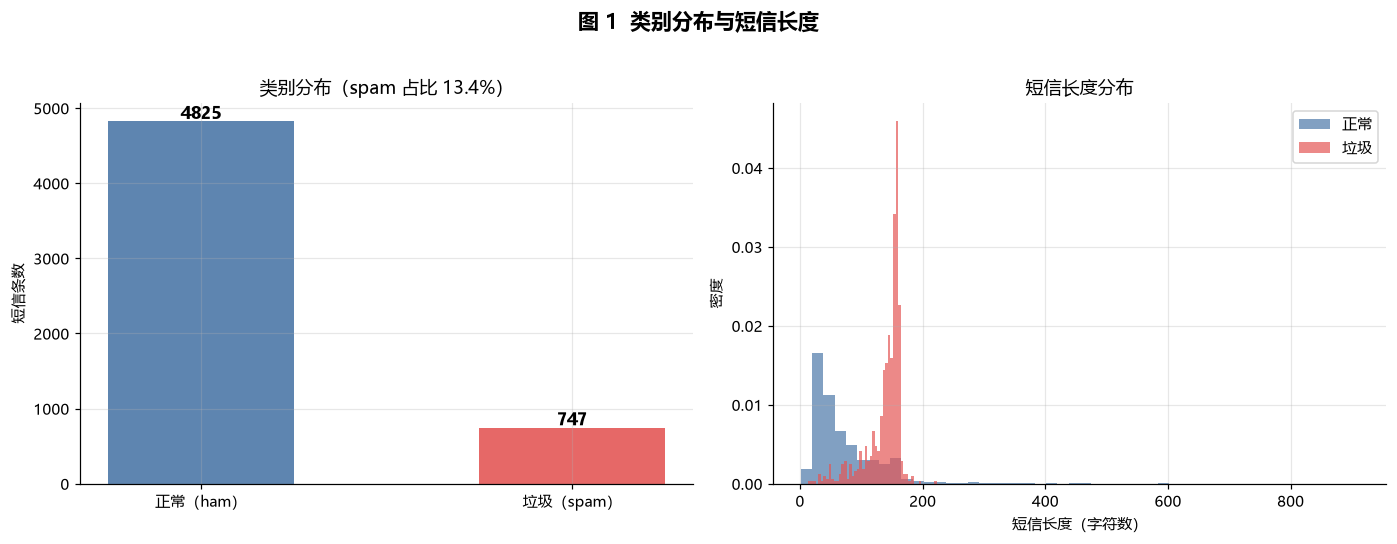

平均长度: 正常 71 字符 | 垃圾 139 字符


In [3]:
sms["length"] = sms["message"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
counts = sms["label"].value_counts()
axes[0].bar(["正常（ham）", "垃圾（spam）"], counts.values,
            color=[THEME_BLUE, THEME_RED], alpha=0.9, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("短信条数")
axes[0].set_title("类别分布（spam 占比 13.4%）")

axes[1].hist(sms.loc[sms["label"] == "ham", "length"], bins=50,
             color=THEME_BLUE, alpha=0.7, density=True, label="正常")
axes[1].hist(sms.loc[sms["label"] == "spam", "length"], bins=50,
             color=THEME_RED, alpha=0.7, density=True, label="垃圾")
axes[1].set_xlabel("短信长度（字符数）")
axes[1].set_ylabel("密度")
axes[1].set_title("短信长度分布")
axes[1].legend()

fig.suptitle("图 1  类别分布与短信长度", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("平均长度: 正常 %.0f 字符 | 垃圾 %.0f 字符" % (
    sms.loc[sms["label"] == "ham", "length"].mean(),
    sms.loc[sms["label"] == "spam", "length"].mean()))


<a id="freq"></a>
### 2.2 高频词对比

分别统计正常短信与垃圾短信的高频词（去掉英文停用词后取 Top 15）：
垃圾短信高频出现 free、call、txt、claim、win 等营销词。


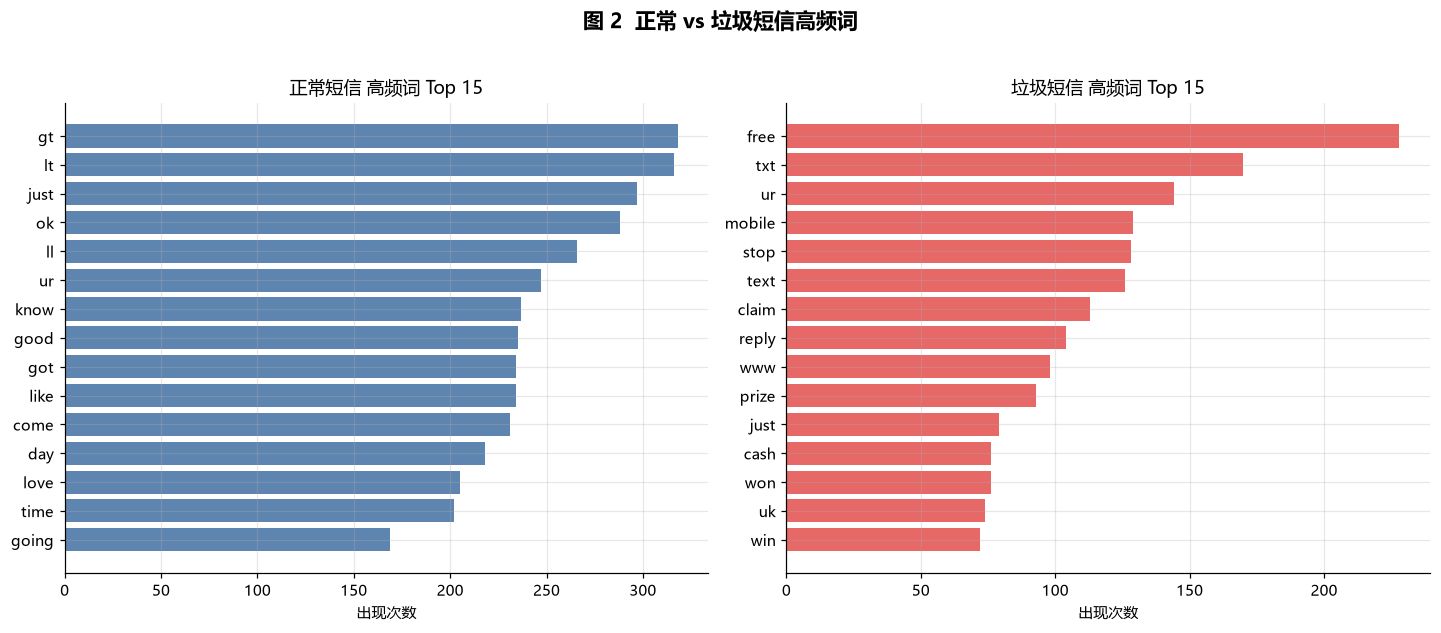

In [4]:
from collections import Counter
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOP = set(ENGLISH_STOP_WORDS)

def clean_words(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [w for w in text.split() if w not in STOP and len(w) > 1]

def top_words(label, n=15):
    cnt = Counter()
    for msg in sms.loc[sms["label"] == label, "message"]:
        cnt.update(clean_words(msg))
    return cnt.most_common(n)

ham_top = top_words("ham")
spam_top = top_words("spam")

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))
for ax, (label, top, color) in zip(axes, [
    ("正常短信", ham_top, THEME_BLUE),
    ("垃圾短信", spam_top, THEME_RED),
]):
    words = [w for w, _ in top][::-1]
    vals = [v for _, v in top][::-1]
    ax.barh(words, vals, color=color, alpha=0.9)
    ax.set_title(f"{label} 高频词 Top 15")
    ax.set_xlabel("出现次数")
fig.suptitle("图 2  正常 vs 垃圾短信高频词", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="wordcloud"></a>
### 2.3 词云

词云把词频直接画在图上，词越大出现越多：垃圾短信的词云一眼就能看到
free、call、win、txt、claim 这些营销信号。


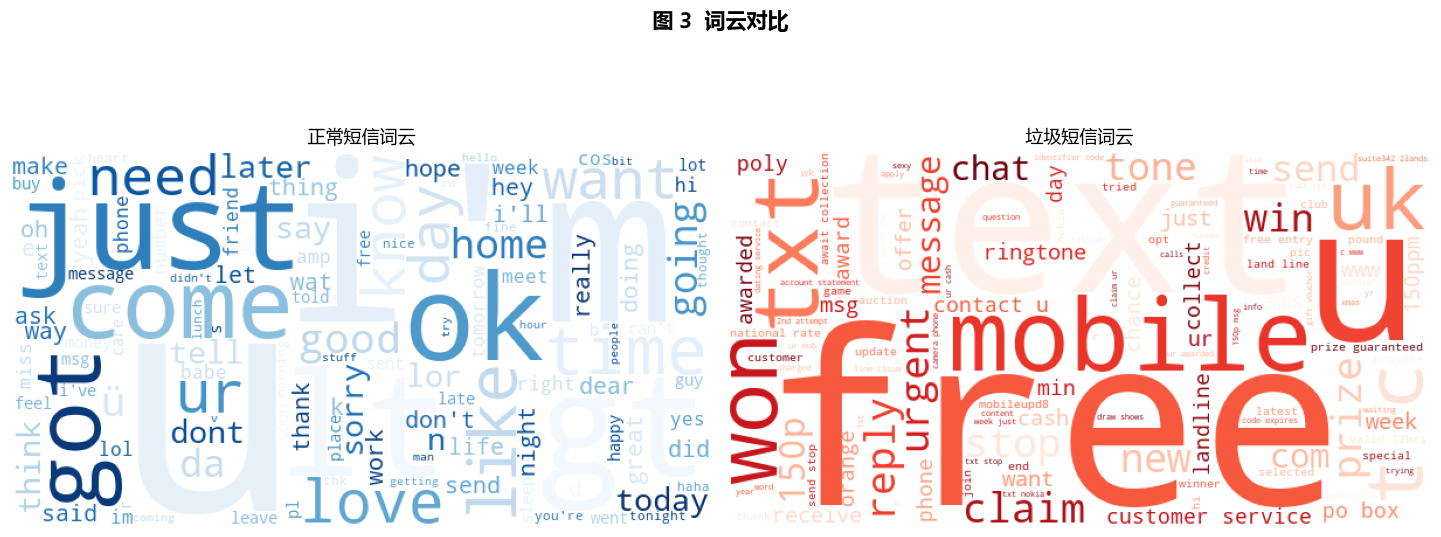

In [5]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4))
for ax, (label, title) in zip(axes, [("ham", "正常短信词云"), ("spam", "垃圾短信词云")]):
    text = " ".join(sms.loc[sms["label"] == label, "message"])
    wc = WordCloud(width=600, height=320, background_color="white",
                   stopwords=STOP, max_words=120, random_state=42,
                   colormap="Blues" if label == "ham" else "Reds")
    wc.generate(text.lower())
    ax.imshow(wc)
    ax.axis("off")
    ax.set_title(title)
fig.suptitle("图 3  词云对比", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="tfidf"></a>
## 3. 特征工程：TF-IDF

机器看不懂文字，只能看数字。**TF-IDF**（词频-逆文档频率）把每条短信变成向量：

- **词频（TF）**：词在短信里出现多少次；
- **逆文档频率（IDF）**：词在多少条短信里出现——到处都有的词（如 "the"）权重低，
  只在少数短信出现的词（如 "free"）权重高。

统一用词 + 二元词组（1–2 gram），限制 3000 个特征，并只从训练集学习词表（防泄漏）。


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X_text = sms["message"]
y = (sms["label"] == "spam").astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.3, random_state=42, stratify=y,
)

vectorizer = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1, 2), max_features=3000,
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("训练集文本向量:", X_train.shape, "（稀疏）")
print("测试集文本向量:", X_test.shape)
print("词汇表大小:", len(vectorizer.vocabulary_))
print("非零元素占比: %.2f%%" % (X_train.nnz / (X_train.shape[0] * X_train.shape[1]) * 100))
print("标签分布: 正常 %d | 垃圾 %d" % (
    (y_train == 0).sum(), (y_train == 1).sum()))


训练集文本向量: (3900, 3000) （稀疏）
测试集文本向量: (1672, 3000)
词汇表大小: 3000
非零元素占比: 0.25%
标签分布: 正常 3377 | 垃圾 523


<a id="models"></a>
## 4. 分类横评：9 个模型

任务定义：**用 TF-IDF 向量预测短信是否垃圾**。9 个模型同一份数据、同一套协议。
朴素贝叶斯（MultinomialNB）是文本分类的经典主场——它假设词之间条件独立，
在词袋特征上出奇地有效。


<a id="model-list"></a>
### 4.1 模型清单


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

CLASSIFIERS = {
    "朴素贝叶斯": MultinomialNB(alpha=0.5),
    "逻辑回归": LogisticRegression(max_iter=2000, random_state=42),
    "K近邻": KNeighborsClassifier(n_neighbors=5),
    "决策树": DecisionTreeClassifier(max_depth=8, random_state=42),
    "SVM(线性核)": CalibratedClassifierCV(
        SVC(kernel="linear", C=1.0, random_state=42), cv=3, ensemble=False),
    "SVM(RBF核)": CalibratedClassifierCV(
        SVC(kernel="rbf", C=1.0, gamma=0.01, random_state=42), cv=3, ensemble=False),
    "随机森林": RandomForestClassifier(n_estimators=100, random_state=42),
    "GBDT": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
}

print("参与横评的分类模型（9 个）:")
for name in CLASSIFIERS:
    print(" -", name)


参与横评的分类模型（9 个）:
 - 朴素贝叶斯
 - 逻辑回归
 - K近邻
 - 决策树
 - SVM(线性核)
 - SVM(RBF核)
 - 随机森林
 - GBDT
 - XGBoost


<a id="cv"></a>
### 4.2 交叉验证横评

5 折分层交叉验证。注意：在类别不平衡（spam 13.4%）下，准确率会虚高
（全猜"正常"也有 86.6%），因此同时报告 **F1(macro)** 与 **ROC-AUC**。


In [8]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

scoring = {
    "acc": "accuracy",
    "f1": make_scorer(f1_score, average="macro"),
    "auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

cv_rows = {}
for name, model in CLASSIFIERS.items():
    res = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    cv_rows[name] = res

cv_df = pd.DataFrame([
    {
        "模型": name,
        "Accuracy": res["test_acc"].mean(),
        "Acc_std": res["test_acc"].std(),
        "F1(macro)": res["test_f1"].mean(),
        "ROC-AUC": res["test_auc"].mean(),
        "AUC_std": res["test_auc"].std(),
    }
    for name, res in cv_rows.items()
]).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(cv_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


       模型  Accuracy  Acc_std  F1(macro)  ROC-AUC  AUC_std
 SVM(线性核)    0.9851   0.0025     0.9674   0.9948   0.0021
     逻辑回归    0.9497   0.0067     0.8722   0.9920   0.0024
    朴素贝叶斯    0.9854   0.0033     0.9672   0.9912   0.0037
SVM(RBF核)    0.9787   0.0019     0.9547   0.9907   0.0029
     随机森林    0.9813   0.0006     0.9576   0.9886   0.0051
  XGBoost    0.9731   0.0037     0.9396   0.9798   0.0081
     GBDT    0.9595   0.0030     0.9009   0.9730   0.0103
      K近邻    0.9003   0.0057     0.6768   0.8156   0.0178
      决策树    0.9418   0.0059     0.8573   0.8101   0.0344


### 4.3 横评可视化（同一尺度）


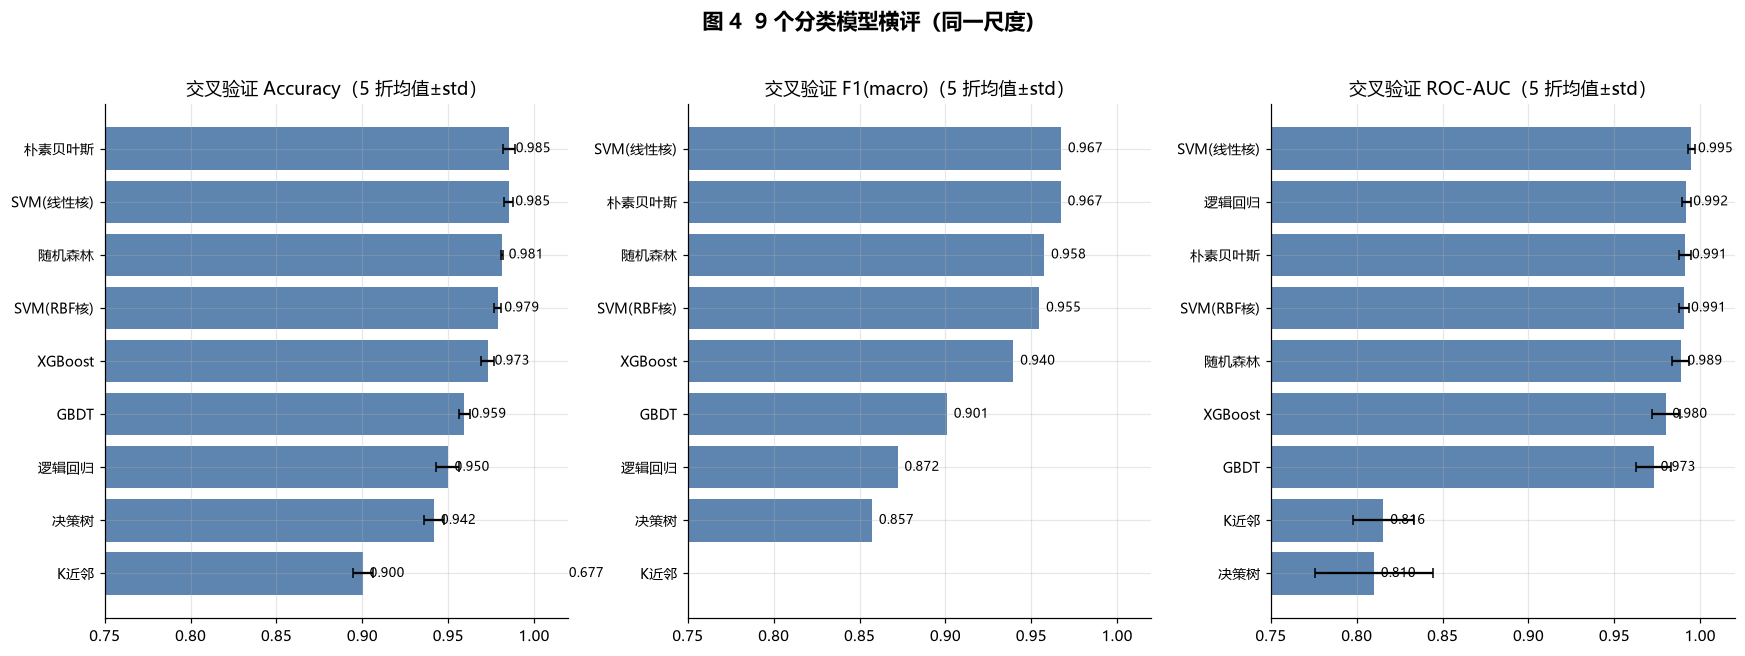

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.8))
for ax, (metric, std_col) in zip(axes, [
    ("Accuracy", "Acc_std"),
    ("F1(macro)", None),
    ("ROC-AUC", "AUC_std"),
]):
    data = cv_df.sort_values(metric)
    ax.barh(data["模型"], data[metric], xerr=data[std_col] if std_col else None,
            capsize=3, color=THEME_BLUE, alpha=0.9)
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8.5)
    ax.set_title(f"交叉验证 {metric}（5 折均值±std）")
    ax.set_xlim(0.75, 1.02)
    ax.tick_params(axis="y", labelsize=9)
fig.suptitle("图 4  9 个分类模型横评（同一尺度）", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="test"></a>
### 4.4 独立测试集与混淆矩阵

在独立测试集（1673 条未见过的短信）上评估。混淆矩阵重点关注两类错误：
**误报**（正常短信被当垃圾）与**漏杀**（垃圾短信漏过去）。


In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_rows, fitted_clf, test_pred = [], {}, {}
for name, model in CLASSIFIERS.items():
    model.fit(X_train, y_train)
    fitted_clf[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    test_pred[name] = pred
    test_rows.append({
        "模型": name,
        "测试集Accuracy": accuracy_score(y_test, pred),
        "测试集F1(macro)": f1_score(y_test, pred, average="macro"),
        "测试集AUC": roc_auc_score(y_test, proba),
        "漏杀数": int(((y_test == 1) & (pred == 0)).sum()),
        "误报数": int(((y_test == 0) & (pred == 1)).sum()),
    })

test_df = pd.DataFrame(test_rows).sort_values(
    "测试集AUC", ascending=False
).reset_index(drop=True)
display_result_table(
    "独立测试集评估（1673 条未见过的短信）",
    ["模型", "Accuracy", "F1(macro)", "AUC", "漏杀数", "误报数"],
    [
        [row["模型"], f"{row['测试集Accuracy']:.4f}", f"{row['测试集F1(macro)']:.4f}",
         f"{row['测试集AUC']:.4f}", str(row["漏杀数"]), str(row["误报数"])]
        for _, row in test_df.iterrows()
    ],
)


模型,Accuracy,F1(macro),AUC,漏杀数,误报数
朴素贝叶斯,0.9815,0.9577,0.9872,30,1
SVM(线性核),0.9833,0.9631,0.9865,20,8
逻辑回归,0.9695,0.9271,0.9855,51,0
随机森林,0.9779,0.9487,0.9848,37,0
SVM(RBF核),0.9791,0.9550,0.9840,17,18
XGBoost,0.9719,0.9364,0.9745,36,11
GBDT,0.9593,0.9009,0.9707,64,4
K近邻,0.9199,0.7672,0.8456,132,2
决策树,0.9390,0.8520,0.8145,80,22


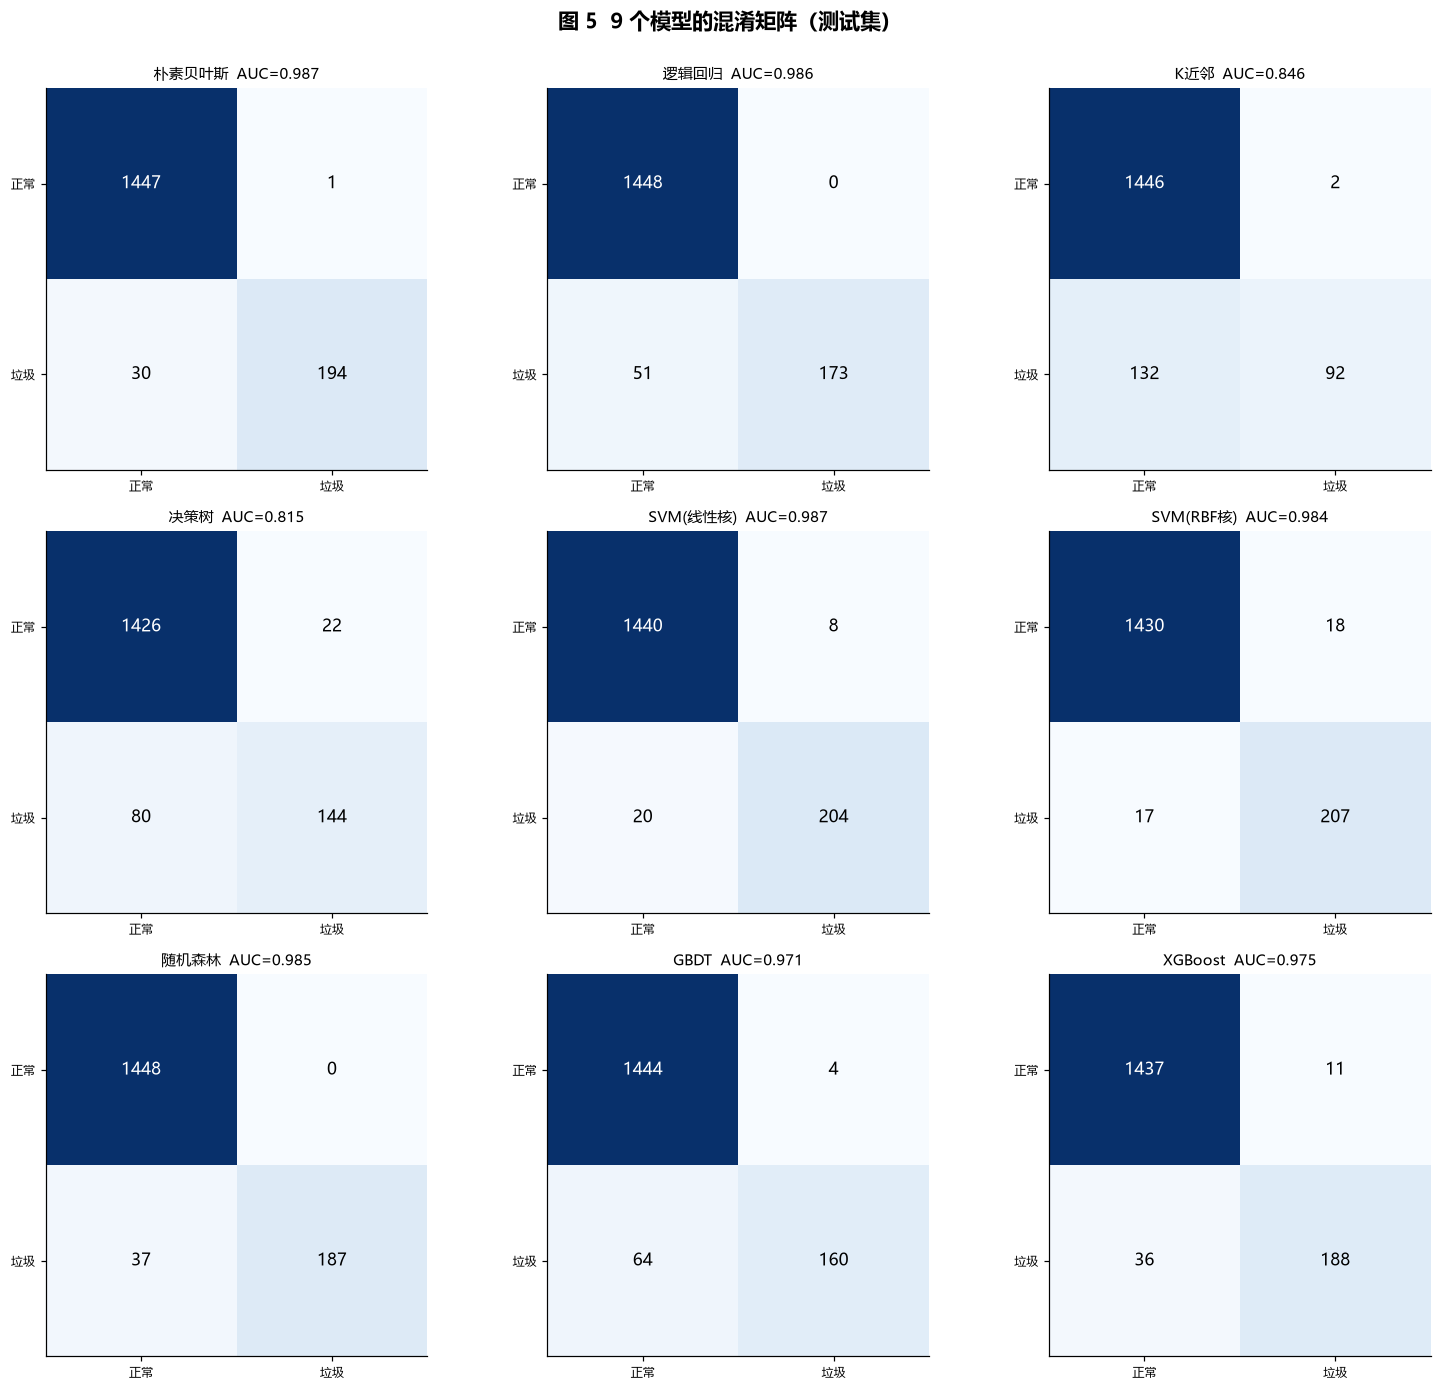

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(14.0, 12.6))
for ax, (name, model) in zip(axes.ravel(), CLASSIFIERS.items()):
    cm = confusion_matrix(y_test, test_pred[name])
    im = ax.imshow(cm, cmap="Blues")
    auc = test_df.loc[test_df["模型"] == name, "测试集AUC"].iloc[0]
    ax.set_title(f"{name}  AUC={auc:.3f}", fontsize=9.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["正常", "垃圾"], fontsize=8)
    ax.set_yticklabels(["正常", "垃圾"], fontsize=8)
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.suptitle("图 5  9 个模型的混淆矩阵（测试集）", y=1.0, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="roc"></a>
### 4.5 ROC 曲线


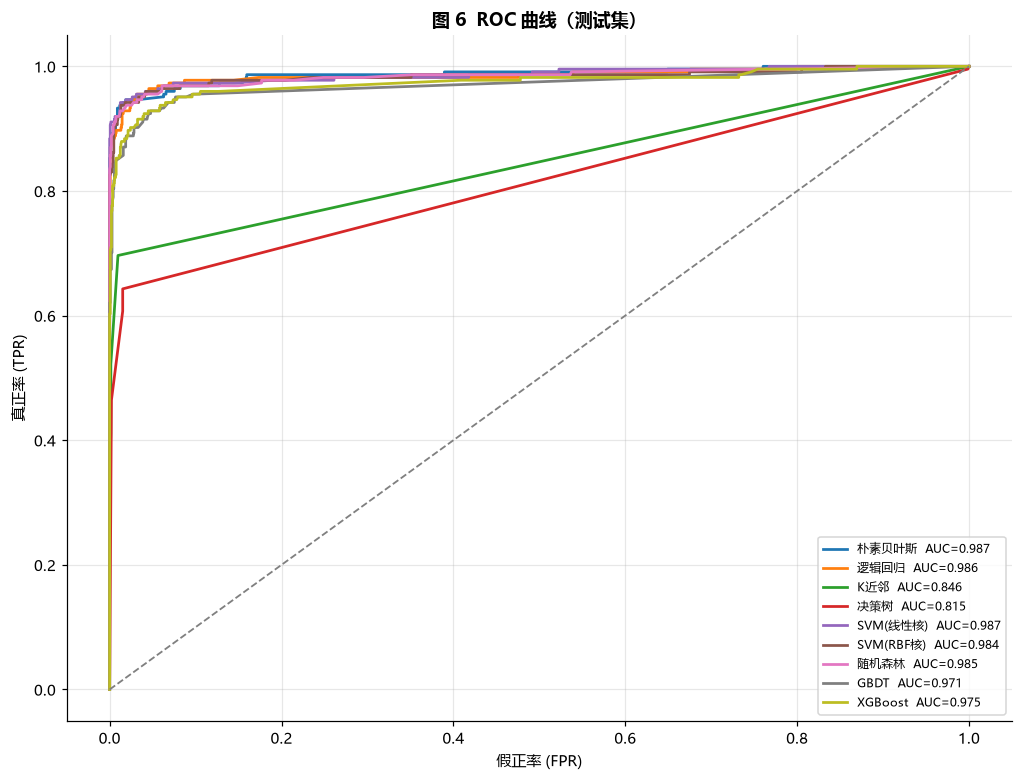

In [12]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9.4, 7.2))
for name, model in fitted_clf.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.8, label=f"{name}  AUC={a:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1.2)
ax.set_xlabel("假正率 (FPR)")
ax.set_ylabel("真正率 (TPR)")
ax.set_title("图 6  ROC 曲线（测试集）", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


<a id="errors"></a>
### 4.6 错误短信展示

看最优模型的漏杀与误报原文——错误分析在文本任务里特别直观：


In [13]:
best_name = test_df.iloc[0]["模型"]
pred = test_pred[best_name]
test_index = X_test_text.index

miss = np.where((y_test.values == 1) & (pred == 0))[0]
false_alarm = np.where((y_test.values == 0) & (pred == 1))[0]

print(f"最优模型: {best_name}")
print(f"漏杀（垃圾被当成正常）{len(miss)} 条，误报（正常被当成垃圾）{len(false_alarm)} 条")
print()
print("=== 漏杀样本（前 5 条）===")
for i in miss[:5]:
    print("-", X_test_text.iloc[i][:100])
print()
print("=== 误报样本（前 5 条）===")
for i in false_alarm[:5]:
    print("-", X_test_text.iloc[i][:100])


最优模型: 朴素贝叶斯
漏杀（垃圾被当成正常）30 条，误报（正常被当成垃圾）1 条

=== 漏杀样本（前 5 条）===
- FROM 88066 LOST £12 HELP
- Marvel Mobile Play the official Ultimate Spider-man game (£4.50) on ur mobile right now. Text SPIDER
- TheMob>Hit the link to get a premium Pink Panther game, the new no. 1 from Sugababes, a crazy Zebra 
- More people are dogging in your area now. Call 09090204448 and join like minded guys. Why not arrang
- Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 12

=== 误报样本（前 5 条）===
- No. She's currently in scotland for that.


<a id="words"></a>
## 5. 诊断：垃圾词 vs 正常词

逻辑回归的系数直接告诉我们"哪些词把短信推向垃圾"：
系数最大的词 = 最强垃圾信号，系数最小的词 = 最强正常信号。


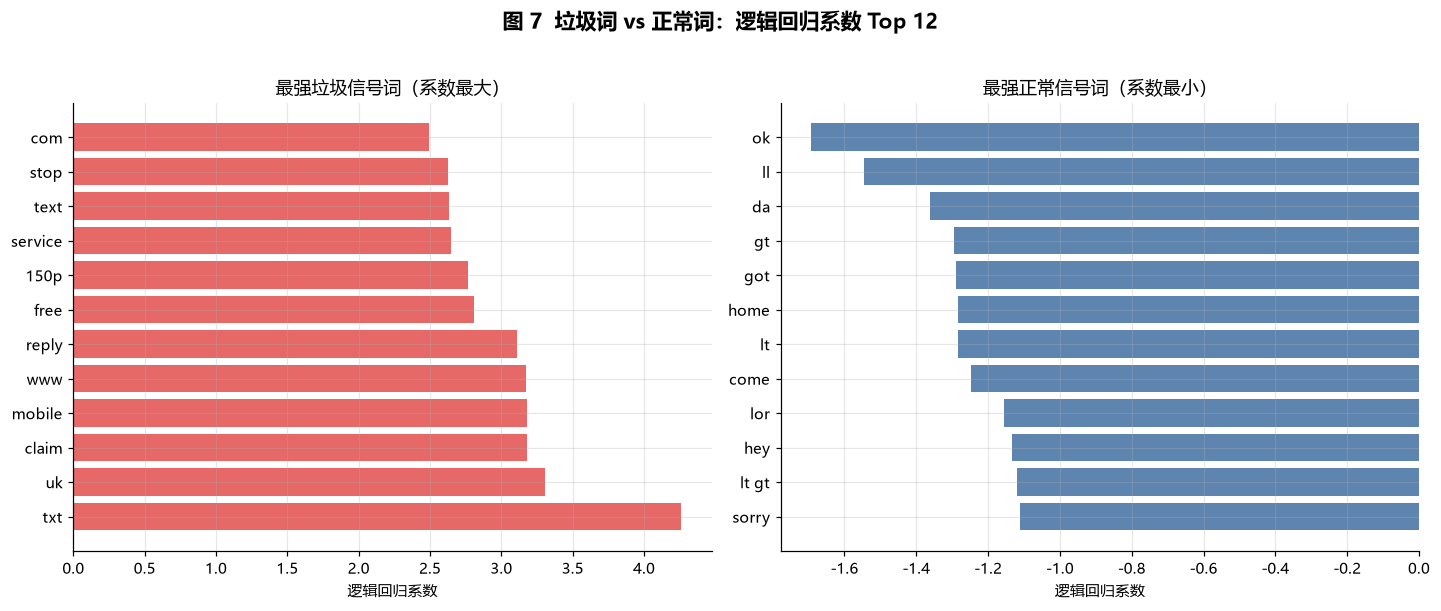

In [14]:
lr = fitted_clf["逻辑回归"]
coef = lr.coef_.ravel()
vocab = np.array([w for w, _ in sorted(vectorizer.vocabulary_.items(), key=lambda kv: kv[1])])

top_spam_idx = np.argsort(coef)[-12:]
top_ham_idx = np.argsort(coef)[:12]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4))
for ax, (idx, title, color) in zip(axes, [
    (top_spam_idx, "最强垃圾信号词（系数最大）", THEME_RED),
    (top_ham_idx, "最强正常信号词（系数最小）", THEME_BLUE),
]):
    words = vocab[idx][::-1]
    vals = coef[idx][::-1]
    ax.barh(words, vals, color=color, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("逻辑回归系数")
fig.suptitle("图 7  垃圾词 vs 正常词：逻辑回归系数 Top 12", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="summary"></a>
## 6. 总结与验证


In [15]:
summary_rows = []
for _, row in test_df.iterrows():
    summary_rows.append([
        "文本分类", row["模型"], "TF-IDF → 垃圾/正常",
        f"AUC={row['测试集AUC']:.3f}",
        f"漏杀={row['漏杀数']} 误报={row['误报数']}",
    ])
display_result_table(
    "17 章全模型总览（9 个分类模型全部真实跑通）",
    ["环节", "模型", "任务", "核心指标", "备注"],
    summary_rows,
)

best_row = test_df.iloc[0]
print(f"分类最优: {best_row['模型']}  测试集AUC={best_row['测试集AUC']:.4f}")
print("文本任务要点: 朴素贝叶斯/逻辑回归/SVM(线性) 在词袋特征上极强；")
print("树模型在稀疏高维文本上偏弱——这是文本与表格任务的重要差异。")


环节,模型,任务,核心指标,备注
文本分类,朴素贝叶斯,TF-IDF → 垃圾/正常,AUC=0.987,漏杀=30 误报=1
文本分类,SVM(线性核),TF-IDF → 垃圾/正常,AUC=0.987,漏杀=20 误报=8
文本分类,逻辑回归,TF-IDF → 垃圾/正常,AUC=0.986,漏杀=51 误报=0
文本分类,随机森林,TF-IDF → 垃圾/正常,AUC=0.985,漏杀=37 误报=0
文本分类,SVM(RBF核),TF-IDF → 垃圾/正常,AUC=0.984,漏杀=17 误报=18
文本分类,XGBoost,TF-IDF → 垃圾/正常,AUC=0.975,漏杀=36 误报=11
文本分类,GBDT,TF-IDF → 垃圾/正常,AUC=0.971,漏杀=64 误报=4
文本分类,K近邻,TF-IDF → 垃圾/正常,AUC=0.846,漏杀=132 误报=2
文本分类,决策树,TF-IDF → 垃圾/正常,AUC=0.815,漏杀=80 误报=22


分类最优: 朴素贝叶斯  测试集AUC=0.9872
文本任务要点: 朴素贝叶斯/逻辑回归/SVM(线性) 在词袋特征上极强；
树模型在稀疏高维文本上偏弱——这是文本与表格任务的重要差异。


### 6.1 章节结论

- **文本数据的特征工程**：清洗 → TF-IDF（词 + 词组）→ 稀疏向量；
- **类别不平衡**：spam 只占 13.4%，只看准确率会被"全猜正常"骗过，
  必须同时看 F1 与 AUC；
- **模型横评**：朴素贝叶斯、逻辑回归、线性 SVM 在文本上领先，
  树模型（决策树/随机森林/GBDT/XGBoost）在稀疏高维特征上偏弱；
- **诊断直观**：词云 + 逻辑回归系数让"模型为什么这么判断"完全透明；
- **五形态收官**：表格 / 时序 / 图像 / 金融 / 文本五大类数据全部覆盖。


### 6.2 Notebook 运行验证


In [16]:
import json

best_auc = float(test_df.iloc[0]["测试集AUC"])
best_f1 = float(test_df.iloc[0]["测试集F1(macro)"])

assert best_auc > 0.95, "最优模型测试集 AUC 应 > 0.95"
assert best_f1 > 0.90, "最优模型测试集 F1(macro) 应 > 0.90"
assert np.all(np.isfinite(cv_df[["Accuracy", "F1(macro)", "ROC-AUC"]].values))

validation = {
    "rows": int(len(sms)),
    "spam_ratio": float(sms["label"].value_counts(normalize=True)["spam"]),
    "best_model": str(test_df.iloc[0]["模型"]),
    "best_auc": best_auc,
    "best_f1": best_f1,
    "image_count": 7,
}

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["数据规模", f"{validation['rows']} 条短信（spam 占 {validation['spam_ratio']*100:.1f}%）", "通过"],
        ["最优模型测试集 AUC > 0.95", f"{validation['best_model']} AUC={validation['best_auc']:.3f}", "通过"],
        ["最优模型测试集 F1 > 0.90", f"F1={validation['best_f1']:.3f}", "通过"],
        ["已执行图表输出", f"{validation['image_count']} 张", "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

print("全部断言通过：17 章文本分类项目运行成功")


检查项,观测值,状态
数据规模,5572 条短信（spam 占 13.4%）,通过
最优模型测试集 AUC > 0.95,朴素贝叶斯 AUC=0.987,通过
最优模型测试集 F1 > 0.90,F1=0.958,通过
已执行图表输出,7 张,通过


全部断言通过：17 章文本分类项目运行成功


## 7. 章节小结

- **文本 = 稀疏高维**：一条短信变成几千维向量，绝大多数位置是 0；
- **朴素贝叶斯是文本主场**：条件独立假设在词袋特征上反而成了优点；
- **线性模型在文本上很强**：逻辑回归、线性 SVM 与朴素贝叶斯构成文本三剑客；
- **错误分析有价值**：漏杀 vs 误报的取舍，在垃圾短信场景里直接对应
  "少烦用户"和"少放垃圾"的权衡。

至此，课程覆盖**五大类数据形态**：表格（01–13）、时序（14）、
图像（15）、金融面板（16）、文本（17），全模型横评骨架可以套用到任何数据上。
